# SETUP & DATA LOADING

Import Libraries

In [ ]:
# Basic libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text processing
import re

# Sklearn basics (we'll use later)
from sklearn.model_selection import train_test_split

LOAD DATASET

In [ ]:
# Load dataset
df = pd.read_csv('/content/ml_resume_dataset_4500.csv')

# Basic preview
df.head()

,id,name,years_experience,highest_degree,skills,current_title,has_portfolio,raw_text,label
0,1,Badhan Shah,9.0,Bachelors,"NLP, GPT",Customer Support,False,Sales professional with strong communication s...,0
1,2,Lamia Sarker,2.0,Masters,"PyTorch, CI/CD, Power BI, Data Visualization, AWS",Administrative Assistant,False,Sales professional with strong communication s...,0
2,3,Badhan Molla,2.0,Bachelors,"AWS, Flask, Machine Learning, Model Deployment...",Computer Vision Engineer,True,Research scientist with strong statistical bac...,1
3,4,Badhan Ahmed,9.0,Bachelors,"Hadoop, Feature Engineering, Docker Compose, O...",Data Entry Operator,True,Customer support representative with some Exce...,0
4,5,Rasel Siddiqui,10.0,Bachelors,"Speech Recognition, Tableau, Azure, TensorFlow",Customer Support,False,Content creator interested in data science but...,0


BASIC INFO CHECK

In [ ]:
# Dataset shape
print("Shape:", df.shape)

# Data types
print("\nData Types:\n", df.dtypes)

# Missing values
print("\nMissing Values:\n", df.isnull().sum())

Shape: (4500, 9)

Data Types:
 id                    int64
name                 object
years_experience    float64
highest_degree       object
skills               object
current_title        object
has_portfolio          bool
raw_text             object
label                 int64
dtype: object

Missing Values:
 id                  0
name                0
years_experience    0
highest_degree      0
skills              0
current_title       0
has_portfolio       0
raw_text            0
label               0
dtype: int64


DROP UNUSED COLUMNS

In [ ]:
# Drop unnecessary columns
df = df.drop(columns=['id', 'name'])

# Remove leakage column
df = df.drop(columns=['current_title'])

# Check updated columns
df.columns

Index(['years_experience', 'highest_degree', 'skills', 'has_portfolio',
       'raw_text', 'label'],
      dtype='object')

# EDA (Exploratory Data Analysis)

TARGET DISTRIBUTION

label
0    3150
1    1350
Name: count, dtype: int64


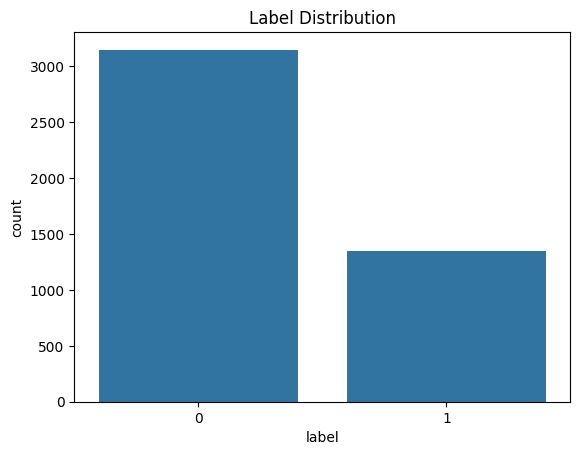

In [ ]:
# Check label distribution
print(df['label'].value_counts())

# Plot distribution
sns.countplot(x='label', data=df)
plt.title("Label Distribution")
plt.show()

TEXT LENGTH ANALYSIS

count    4500.000000
mean       10.854667
std         0.980240
min         9.000000
25%        11.000000
50%        11.000000
75%        11.000000
max        13.000000
Name: text_length, dtype: float64


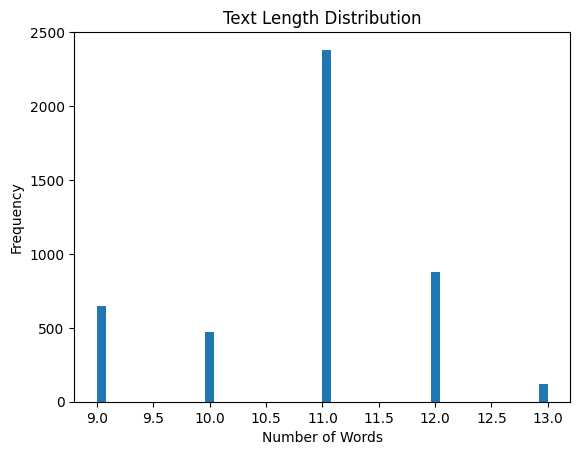

In [ ]:
# Create text length column
df['text_length'] = df['raw_text'].apply(lambda x: len(str(x).split()))

# Basic stats
print(df['text_length'].describe())

# Plot distribution
plt.hist(df['text_length'], bins=50)
plt.title("Text Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

MOST FREQUENT WORDS

In [ ]:
from collections import Counter

# Combine all text
all_text = " ".join(df['raw_text'].astype(str).tolist())

# Tokenize
words = all_text.lower().split()

# Count frequency
word_counts = Counter(words)

# Show top 20 words
print(word_counts.most_common(20))

[('and', 3435), ('with', 3211), ('in', 3137), ('data', 1455), ('experience', 1246), ('ml', 1171), ('to', 924), ('learning', 787), ('experienced', 737), ('engineer', 694), ('limited', 660), ('interest', 647), ('analytics.', 633), ('but', 632), ('communication', 631), ('intern', 626), ('basic', 614), ('excel', 613), ('tasks.', 595), ('strong', 580)]


CHECK DUPLICATES

In [ ]:
# Check duplicate rows
duplicates = df.duplicated().sum()
print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


# DATA CLEANING

BASIC TEXT CLEANING

In [ ]:
# Function for basic cleaning
def clean_text(text):
    text = text.lower()  # lowercase
    text = re.sub(r'[^a-z\s]', '', text)  # remove punctuation/numbers
    text = re.sub(r'\s+', ' ', text).strip()  # remove extra spaces
    return text

# Apply cleaning
df['clean_text'] = df['raw_text'].apply(clean_text)

# Preview
df[['raw_text', 'clean_text']].head()

,raw_text,clean_text
0,Sales professional with strong communication s...,sales professional with strong communication s...
1,Sales professional with strong communication s...,sales professional with strong communication s...
2,Research scientist with strong statistical bac...,research scientist with strong statistical bac...
3,Customer support representative with some Exce...,customer support representative with some exce...
4,Content creator interested in data science but...,content creator interested in data science but...


STOPWORD REMOVAL

In [ ]:
import nltk
from nltk.corpus import stopwords

# Download stopwords
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

# Function to remove stopwords
def remove_stopwords(text):
    return " ".join([word for word in text.split() if word not in stop_words])

# Apply
df['clean_text'] = df['clean_text'].apply(remove_stopwords)

# Preview
df[['raw_text', 'clean_text']].head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,raw_text,clean_text
0,Sales professional with strong communication s...,sales professional strong communication skills...
1,Sales professional with strong communication s...,sales professional strong communication skills...
2,Research scientist with strong statistical bac...,research scientist strong statistical backgrou...
3,Customer support representative with some Exce...,customer support representative excel skills i...
4,Content creator interested in data science but...,content creator interested data science lacks ...


CONTROLLED LEAKAGE CHECK

In [ ]:
# Separate text by label
text_class_0 = " ".join(df[df['label'] == 0]['clean_text'])
text_class_1 = " ".join(df[df['label'] == 1]['clean_text'])

from collections import Counter

# Top words per class
print("Top words in Class 0:\n", Counter(text_class_0.split()).most_common(10))
print("\nTop words in Class 1:\n", Counter(text_class_1.split()).most_common(10))

Top words in Class 0:
 [('experience', 1277), ('data', 1193), ('skills', 958), ('analytics', 953), ('learning', 663), ('limited', 660), ('interest', 647), ('exposure', 646), ('communication', 631), ('intern', 626)]

Top words in Class 1:
 [('engineer', 694), ('ml', 557), ('models', 538), ('experienced', 415), ('scientist', 379), ('deployment', 291), ('detection', 279), ('nlp', 277), ('skilled', 272), ('strong', 271)]


# FEATURE ENGINEERING

TF-IDF VECTORIZATION

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF
tfidf = TfidfVectorizer(max_features=5000)

# Fit and transform
X_text = tfidf.fit_transform(df['clean_text'])

# Check shape
print("TF-IDF shape:", X_text.shape)

TF-IDF shape: (4500, 113)


ADD STRUCTURED FEATURES

In [ ]:
# Convert boolean to int
df['has_portfolio'] = df['has_portfolio'].astype(int)

# One-hot encode highest_degree
df_encoded = pd.get_dummies(df, columns=['highest_degree'], drop_first=True)

# Select structured features
structured_features = df_encoded.drop(columns=['raw_text', 'clean_text', 'skills', 'label'])

# Check shape
print("Structured features shape:", structured_features.shape)
structured_features.head()

Structured features shape: (4500, 5)


,years_experience,has_portfolio,text_length,highest_degree_Masters,highest_degree_PhD
0,9.0,0,11,False,False
1,2.0,0,11,True,False
2,2.0,1,11,False,False
3,9.0,1,11,False,False
4,10.0,0,11,False,False


COMBINE TEXT + STRUCTURED FEATURES

In [ ]:
# Convert structured features to numeric
structured_features = structured_features.astype(float)

# Convert to array
X_struct = structured_features.values

from scipy.sparse import hstack

# Combine with TF-IDF
X = hstack([X_text, X_struct])

# Target
y = df['label']

# Check shape
print("Final feature matrix shape:", X.shape)

Final feature matrix shape: (4500, 118)


# DATA SPLITTING

TRAIN / TEST SPLIT

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Check shapes
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# Check distribution
print("\nTrain label distribution:\n", y_train.value_counts())
print("\nTest label distribution:\n", y_test.value_counts())

Train shape: (3600, 118)
Test shape: (900, 118)

Train label distribution:
 label
0    2520
1    1080
Name: count, dtype: int64

Test label distribution:
 label
0    630
1    270
Name: count, dtype: int64


# MODEL BUILDING

LOGISTIC REGRESSION (BASELINE MODEL)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Initialize model
lr = LogisticRegression(max_iter=1000)

# Train
lr.fit(X_train, y_train)

# Predict
y_pred_lr = lr.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       630
           1       1.00      1.00      1.00       270

    accuracy                           1.00       900
   macro avg       1.00      1.00      1.00       900
weighted avg       1.00      1.00      1.00       900



HARDEN THE MODEL (FIX OVERFITTING)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Reduce feature space
tfidf = TfidfVectorizer(max_features=50)

X_text = tfidf.fit_transform(df['clean_text'])

print("New TF-IDF shape:", X_text.shape)

New TF-IDF shape: (4500, 50)


REBUILD FINAL FEATURE MATRIX

In [ ]:
# Combine again
from scipy.sparse import hstack

X_struct = structured_features.values  # already numeric
X = hstack([X_text, X_struct])

y = df['label']

print("Final shape after reduction:", X.shape)

Final shape after reduction: (4500, 55)


RE-SPLIT DATA

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (3600, 55)
Test: (900, 55)


RETRAIN LOGISTIC REGRESSION

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Train model
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

# Predict
y_pred_lr = lr.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       630
           1       1.00      1.00      1.00       270

    accuracy                           1.00       900
   macro avg       1.00      1.00      1.00       900
weighted avg       1.00      1.00      1.00       900



REMOVE TEXT FEATURES (TEST BASELINE)

In [ ]:
# Use ONLY structured features
X_struct_only = structured_features.values

# Split again
from sklearn.model_selection import train_test_split

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_struct_only, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Train Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_s, y_train_s)

y_pred_s = lr.predict(X_test_s)

# Evaluate
print("Accuracy (structured only):", accuracy_score(y_test_s, y_pred_s))
print("\nClassification Report:\n", classification_report(y_test_s, y_pred_s))

Accuracy (structured only): 0.8722222222222222

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.93      0.91       630
           1       0.83      0.73      0.77       270

    accuracy                           0.87       900
   macro avg       0.86      0.83      0.84       900
weighted avg       0.87      0.87      0.87       900



# ADVANCED MODEL COMPARISON

RANDOM FOREST (STRUCTURED DATA)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_s, y_train_s)

# Predict
y_pred_rf = rf.predict(X_test_s)

# Evaluate
print("Accuracy (RF - structured):", accuracy_score(y_test_s, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test_s, y_pred_rf))

Accuracy (RF - structured): 0.8744444444444445

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.93      0.91       630
           1       0.83      0.73      0.78       270

    accuracy                           0.87       900
   macro avg       0.86      0.83      0.85       900
weighted avg       0.87      0.87      0.87       900



SVM (STRUCTURED DATA)

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Train SVM
svm = SVC(kernel='linear')
svm.fit(X_train_s, y_train_s)

# Predict
y_pred_svm = svm.predict(X_test_s)

# Evaluate
print("Accuracy (SVM - structured):", accuracy_score(y_test_s, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test_s, y_pred_svm))

Accuracy (SVM - structured): 0.87

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.95      0.91       630
           1       0.85      0.69      0.76       270

    accuracy                           0.87       900
   macro avg       0.86      0.82      0.84       900
weighted avg       0.87      0.87      0.87       900



# VALIDATION

CROSS-VALIDATION (LOGISTIC REGRESSION)

In [ ]:
from sklearn.model_selection import cross_val_score

# Cross-validation (5-fold)
scores = cross_val_score(
    LogisticRegression(max_iter=1000),
    X_struct_only,
    y,
    cv=5,
    scoring='accuracy'
)

print("Cross-validation scores:", scores)
print("Mean accuracy:", scores.mean())

Cross-validation scores: [0.87333333 0.88222222 0.86555556 0.87777778 0.85555556]
Mean accuracy: 0.8708888888888888


SAVE MODEL + PREPROCESSING

In [ ]:
import joblib

# Save model
joblib.dump(lr, 'resume_model.pkl')

# Save feature columns (very important)
joblib.dump(structured_features.columns.tolist(), 'feature_columns.pkl')

print("Model and feature columns saved!")

Model and feature columns saved!


BUILD PREDICTION PIPELINE

In [ ]:
# Load model and columns
import joblib
model = joblib.load('resume_model.pkl')
feature_cols = joblib.load('feature_columns.pkl')

def predict_candidate(years_experience, degree, has_portfolio):

    # Create input dictionary
    input_data = {
        'years_experience': years_experience,
        'has_portfolio': int(has_portfolio),
        'text_length': 11,  # average value (since it's constant)
        'highest_degree_Masters': 1 if degree == 'Masters' else 0,
        'highest_degree_PhD': 1 if degree == 'PhD' else 0
    }

    # Convert to DataFrame
    import pandas as pd
    input_df = pd.DataFrame([input_data])

    # Ensure column order matches
    input_df = input_df.reindex(columns=feature_cols, fill_value=0)

    # Predict
    prediction = model.predict(input_df)[0]

    return prediction

# Test prediction
result = predict_candidate(5, 'Masters', True)
print("Prediction:", result)

Prediction: 1


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
